# 15: Policy Learning, Weighted ATEs, Quantiles, and CVaR

This lesson moves from estimation toward decision targets. Earlier lessons estimated average effects, group effects, conditional-effect summaries, uncertainty, and sensitivity. Those are essential building blocks, but many applied causal questions are not answered by a single ATE.

A decision maker may ask:

- What is the effect for a priority population rather than the full population?
- Which observations should receive treatment if the treatment is optional, costly, or capacity-limited?
- Does treatment help the lower tail of the outcome distribution, more than the mean?
- Does treatment reduce downside risk for vulnerable units?

DoubleML contains several tools for this broader decision layer. In this lesson we use:

- `weights=` in `DoubleMLIRM` for **weighted ATEs**.
- `DoubleMLIRM.policy_tree()` for a simple **policy-learning** rule.
- `DoubleMLQTE` for **quantile treatment effects**.
- `DoubleMLCVAR` for **lower-tail potential-outcome risk**.

The big conceptual warning is that these targets are still causal targets. A policy tree is more than a prediction tree. A weighted ATE is more than a filtered average. A QTE is more than a histogram comparison. Each result inherits the same identification assumptions as the base causal design: no unmeasured confounding conditional on the controls, overlap, and a stable treatment definition.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Policy Learning, Weighted ATEs, Quantiles, And CVaR**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the lesson separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment turns estimates into action rules. The important outcome is estimation accuracy and whether the learned rule improves a decision under constraints. The experiment studies distributional effects. Mean effects can miss lower-tail or upper-tail changes that matter for risk-sensitive decisions.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.

This lesson also uses a real-data-style companion as a decision-science illustration. Because real data do not reveal both potential outcomes, read any real-data result as a workflow illustration and avoid treating it as a verified oracle benchmark.


## Mathematical Foundation

<!-- math-foundation-note -->

Policy learning chooses an action rule $\pi(X)$ using estimated causal gains. A value function is

$$
V(\pi)=\mathbb{E}\{Y(\pi(X))\}.
$$

For binary treatment with cost $c(X)$, a simple rule is

$$
\pi(X)=\mathbf{1}\{\widehat\tau(X)>c(X)\}.
$$

The policy metrics are about expected decisions under uncertainty, support, and costs.





## Tutorial Workflow

#### Setup

This setup block prepares the tutorial output folders and imports the libraries used throughout the lesson. The code is visible so a reader can reproduce the environment and see exactly which DoubleML classes are being used.

The warning filters are narrow. They silence lesson-environment noise and a familiar scikit-learn feature-name warning, while leaving model and data problems visible.


In [1]:
from pathlib import Path
import os
import warnings
# Find the repository root from wherever the notebook is executed.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
# Set Matplotlib's cache before importing pyplot so notebook execution stays quiet.
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error
from sklearn.tree import export_text, plot_tree
import doubleml as dml
from doubleml import DoubleMLCVAR, DoubleMLData, DoubleMLIRM, DoubleMLQTE
NOTEBOOK_PREFIX = "15"
RANDOM_SEED = 150
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)
print(f"Project root: {PROJECT_ROOT}")
print(f"DoubleML version: {dml.__version__}")
print(f"Outputs will be written to: {OUTPUT_DIR}")


Project root: repository root
DoubleML version: 0.11.2
Outputs will be written to: notebooks/tutorials/doubleml/outputs


The setup confirms the installed DoubleML version and the shared output folder. Every file created by this lesson uses prefix `15`.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Helper Functions

The helpers below keep the lesson focused on causal ideas rather than file paths and repeated formatting. Two helpers deserve special attention:

- `lower_tail_cvar()` computes an oracle lower-tail average in the synthetic data. This is only possible here because both potential outcomes are stored by the simulator.
- `fit_weighted_irm()` wraps the `DoubleMLIRM(weights=...)` workflow so the weighted ATE section stays compact.


In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, filename):
    """
    Idea: Save a result table to the notebook table directory and return the same DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return df
def save_dataset(df, filename):
    """
    Idea: Write the constructed dataset to the tutorial output folder so later notebooks or cells can reuse it.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Same dataset after writing it to the tutorial dataset directory.
    """
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return df
def sigmoid(values):
    """
    Idea: Map a linear score to a probability on the 0 to 1 scale for treatment assignment or simulation logic.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    
    Returns
    -------
    np.ndarray
        Probability-scale values obtained by applying the logistic transform elementwise.
    """
    values = np.asarray(values)
    return 1.0 / (1.0 + np.exp(-values))
def rmse(y_true, y_pred):
    """
    Idea: Compute root mean squared error between an oracle target and an estimated or predicted value.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared error between the reference values and predictions.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))
def normalize_weights(weights):
    """
    Idea: Rescale observation weights so their mean is one while preserving their relative emphasis.
    
    Parameters
    ----------
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    np.ndarray
        Observation weights rescaled to have mean one.
    """
    weights = np.asarray(weights, dtype=float)
    if weights.mean() <= 0:
        raise ValueError("Weights must have positive mean.")
    return weights / weights.mean()
def weighted_mean(values, weights):
    """
    Idea: Compute a mean that reflects the target population or policy weighting scheme.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Weighted average of the supplied values.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return float(np.sum(values * weights) / np.sum(weights))
def lower_tail_cvar(values, alpha):
    """
    Idea: Compute the average outcome in the lower tail of a distribution for CVaR-style decision analysis.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    alpha : float
        Significance level, transparency value, or tuning parameter used by the diagnostic.
    
    Returns
    -------
    float
        Mean of the lower-tail outcomes at the requested tail probability.
    """
    values = np.asarray(values, dtype=float)
    cutoff = np.quantile(values, alpha)
    return float(values[values <= cutoff].mean())
def make_irm_data(frame, x_cols):
    """
    Idea: Construct the interactive regression model data used in the Helper Functions section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    x_cols : list[str]
        Covariate column names used as model inputs.
    
    Returns
    -------
    DoubleMLData
        DoubleMLData object configured for binary-treatment IRM estimation.
    """
    return DoubleMLData(frame, y_col="outcome", d_cols="treatment", x_cols=x_cols)
def fit_weighted_irm(frame, x_cols, ml_g, ml_m, weights=None, n_folds=3):
    """
    Idea: Fit the weighted interactive regression model model and return the fitted object or summary needed for interpretation.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    x_cols : list[str]
        Covariate column names used as model inputs.
    ml_g : object
        Outcome-regression learner used by the DoubleML score.
    ml_m : object
        Treatment or propensity nuisance learner used by the DoubleML estimator.
    weights : array-like
        Observation weights defining the target population or policy objective.
    n_folds : int
        Number of folds used for cross-fitting or validation.
    
    Returns
    -------
    DoubleMLIRM
        Fitted weighted IRM model for the requested target population.
    """
    dml_data = make_irm_data(frame, x_cols)
    model = DoubleMLIRM(
        dml_data,
        ml_g=clone(ml_g),
        ml_m=clone(ml_m),
        n_folds=n_folds,
        n_rep=1,
        score="ATE",
        weights=weights,
    )
    model.fit()
    return model
def extract_irm_row(label, model, oracle_effect, weights=None):
    """
    Idea: Extract the interactive regression model row from a fitted object or result table so it can be reported consistently.
    
    Parameters
    ----------
    label : str
        Short label attached to a scenario, method, or plotted result.
    model : object
        Fitted model or model specification used by the diagnostic.
    oracle_effect : object
        Known synthetic treatment effect used to evaluate estimator behavior.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    dict[str, float]
        IRM summary row with estimate, standard error, confidence interval, and oracle target.
    """
    ci = model.confint()
    if weights is None:
        oracle_value = float(np.mean(oracle_effect))
    else:
        oracle_value = weighted_mean(oracle_effect, weights)
    return {
        "target": label,
        "estimate": float(model.coef[0]),
        "std_error": float(model.se[0]),
        "ci_95_lower": float(ci.iloc[0, 0]),
        "ci_95_upper": float(ci.iloc[0, 1]),
        "oracle_value_in_simulation": oracle_value,
    }


The helper design makes the target explicit each time the lesson estimates something. That is important because this lesson covers several different estimands that should not be mixed together.


### Decision-Target Vocabulary

The table below separates four related ideas. The common thread is that all of them use causal identification, but each answers a different decision question.


| target | plain_language | decision_question | DoubleML_tool |
| --- | --- | --- | --- |
| Weighted ATE | Average effect after assigning more importance to some observations. | What is the effect for the population we care most about? | DoubleMLIRM(weights=...) |
| Policy tree | A shallow decision rule that recommends treatment when the orthogonal benefit signal is positive. | Who should receive treatment under a simple, auditable rule? | DoubleMLIRM.policy_tree() |
| QTE | Difference between treated and untreated potential-outcome quantiles. | Does treatment shift the lower, middle, or upper part of the outcome distribution? | DoubleMLQTE |
| CVaR | Average potential outcome inside a lower tail, such as the worst 10% or 20%. | Does treatment improve downside outcomes for the worst-off cases? | DoubleMLCVAR |


The most common mistake is to describe all four targets as if they were the same effect. They are not. The weighted ATE is still a mean. The QTE is about marginal quantiles of potential outcomes. CVaR is about tail averages. A policy tree is a rule optimized against an orthogonal benefit signal.


### Synthetic Decision Dataset

We create a binary-treatment, continuous-outcome dataset with three features that matter for decisions:

- `need_z`: higher values mean the treatment is more useful.
- `margin_z`: higher values also make the treatment more useful.
- `risk_z`: high values can make the treatment less useful, even though treatment also partly protects against downside shocks.

The simulator stores both potential outcomes, `y0_oracle` and `y1_oracle`, so the lesson can compare estimates with oracle values. Real observational data would only contain the observed outcome.


In [3]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 1_400
x_cols = ["need_z", "engagement_z", "risk_z", "margin_z", "tenure_z", "friction_z"]
decision_df = pd.DataFrame(rng.normal(size=(n_obs, len(x_cols))), columns=x_cols)
propensity_logit = (
    -0.05
    + 0.45 * decision_df["need_z"]
    + 0.35 * decision_df["engagement_z"]
    - 0.35 * decision_df["risk_z"]
    + 0.25 * decision_df["margin_z"]
    - 0.25 * decision_df["friction_z"]
    + 0.15 * decision_df["need_z"] * decision_df["margin_z"]
)
decision_df["propensity_true"] = 0.08 + 0.84 * sigmoid(propensity_logit)
decision_df["treatment"] = rng.binomial(1, decision_df["propensity_true"])
decision_df["high_need_flag"] = (decision_df["need_z"] > 0.5).astype(int)
decision_df["high_risk_flag"] = (decision_df["risk_z"] > 0.8).astype(int)
decision_df["high_margin_flag"] = (decision_df["margin_z"] > 0.5).astype(int)
# This direct component is only part of the individual effect; the potential outcomes below also include downside-risk mitigation.
decision_df["direct_tau_component"] = (
    0.18
    + 0.38 * decision_df["high_need_flag"]
    + 0.24 * decision_df["high_margin_flag"]
    - 0.70 * decision_df["high_risk_flag"]
    + 0.16 * decision_df["need_z"] * decision_df["engagement_z"]
    + 0.08 * decision_df["margin_z"]
    - 0.10 * decision_df["friction_z"]
)
baseline_outcome = (
    1.30
    + 0.50 * decision_df["need_z"]
    + 0.35 * decision_df["engagement_z"]
    - 0.50 * decision_df["risk_z"]
    + 0.18 * decision_df["tenure_z"]
    - 0.25 * decision_df["friction_z"]
    + 0.30 * decision_df["margin_z"]
)
downside_probability = np.clip(
    0.18 + 0.16 * decision_df["high_risk_flag"] + 0.06 * decision_df["friction_z"],
    0.05,
    0.55,
)
downside_size = rng.exponential(scale=0.80 + 0.45 * decision_df["high_risk_flag"], size=n_obs)
downside_event = rng.binomial(1, downside_probability)
downside_shock = downside_event * downside_size
# Treatment partly mitigates downside shocks, so distributional effects can differ from mean effects.
y0_noise = rng.normal(0, 0.45, n_obs)
y1_noise = rng.normal(0, 0.45, n_obs)
decision_df["y0_oracle"] = baseline_outcome + y0_noise - downside_shock
decision_df["y1_oracle"] = baseline_outcome + decision_df["direct_tau_component"] + y1_noise - 0.45 * downside_shock
decision_df["true_effect"] = decision_df["y1_oracle"] - decision_df["y0_oracle"]
decision_df["outcome"] = np.where(decision_df["treatment"].eq(1), decision_df["y1_oracle"], decision_df["y0_oracle"])
decision_df["segment"] = np.select(
    [decision_df["need_z"] > 0.7, decision_df["risk_z"] > 0.8, decision_df["margin_z"] > 0.7],
    ["high_need", "high_risk", "high_margin"],
    default="general",
)
save_dataset(decision_df, f"{NOTEBOOK_PREFIX}_synthetic_decision_targets_data.csv")
display(decision_df.head())


,need_z,engagement_z,risk_z,margin_z,tenure_z,friction_z,propensity_true,treatment,high_need_flag,high_risk_flag,high_margin_flag,direct_tau_component,y0_oracle,y1_oracle,true_effect,outcome,segment
0,0.0677,0.8918,0.4229,1.6162,-0.7963,-1.9830,0.7040,1,0,0,1,0.7572,-0.1246,2.2629,2.3875,2.2629,high_margin
1,0.7562,1.1468,0.7086,0.9138,-1.8901,-1.8971,0.7329,0,1,0,1,1.2016,2.1127,3.7348,1.6221,2.1127,high_need
2,0.5492,0.9281,-0.0366,0.2273,-0.5660,-1.3405,0.6850,0,1,0,0,0.7938,2.3025,3.6749,1.3724,2.3025,general
3,-0.3250,0.9125,-0.9551,0.2943,-0.6932,0.6529,0.5735,1,0,0,0,0.0908,2.2412,1.4161,-0.8251,1.4161,general
4,0.6946,-0.8707,-0.8854,-0.5182,0.1400,0.3267,0.5005,1,1,0,0,0.3891,1.5236,1.7196,0.1960,1.7196,general


The observed outcome is generated from one of the two potential outcomes based on treatment assignment. The oracle columns make the tutorial testable, but the DoubleML estimators only receive the observed treatment, observed outcome, and observed controls.


#### Field Dictionary

This field dictionary documents the dataset roles. Decision-focused lessons need this clarity because it is easy to accidentally target on variables that are only available in a simulator.


| column | role | description |
| --- | --- | --- |
| need_z | Observed control / policy feature | Standardized need or opportunity signal. |
| engagement_z | Observed control / policy feature | Standardized prior engagement signal. |
| risk_z | Observed control / policy feature | Standardized downside-risk signal. |
| margin_z | Observed control / policy feature | Standardized value or margin signal. |
| tenure_z | Observed control | Standardized tenure or relationship length signal. |
| friction_z | Observed control | Standardized friction or support burden signal. |
| propensity_true | Oracle diagnostic | True treatment probability from the simulator; not used by estimators. |
| treatment | Treatment | Binary treatment or exposure indicator. |
| direct_tau_component | Oracle diagnostic | Direct mean-shift component before downside-risk mitigation. |
| y0_oracle | Oracle diagnostic | Potential outcome under no treatment; unavailable in real data. |
| y1_oracle | Oracle diagnostic | Potential outcome under treatment; unavailable in real data. |
| true_effect | Oracle diagnostic | Individual treatment effect y1_oracle - y0_oracle; unavailable in real data. |
| outcome | Outcome | Observed outcome corresponding to the observed treatment. |
| segment | Reporting group | Mutually exclusive teaching segment used for diagnostics and summaries. |


The oracle columns are clearly labeled as diagnostics. That prevents a common tutorial mistake: letting simulated information leak into the estimator and then overestimating how easy the problem is.





## Diagnostics and Interpretation

### Data Audit

This audit checks treatment rate, overlap, mean effect, and downside-risk scale. Since this lesson studies decision targets, it also reports the share of observations with positive oracle treatment effects.


In [4]:
data_audit = pd.DataFrame(
    [
        {"metric": "rows", "value": len(decision_df)},
        {"metric": "treatment_rate", "value": decision_df["treatment"].mean()},
        {"metric": "true_ate", "value": decision_df["true_effect"].mean()},
        {"metric": "share_positive_oracle_effect", "value": decision_df["true_effect"].gt(0).mean()},
        {"metric": "oracle_policy_increment", "value": np.maximum(decision_df["true_effect"], 0).mean()},
        {"metric": "min_true_propensity", "value": decision_df["propensity_true"].min()},
        {"metric": "max_true_propensity", "value": decision_df["propensity_true"].max()},
        {"metric": "outcome_mean", "value": decision_df["outcome"].mean()},
        {"metric": "outcome_std", "value": decision_df["outcome"].std()},
    ]
)
save_table(data_audit, f"{NOTEBOOK_PREFIX}_data_audit.csv")
display(data_audit)


,metric,value
0,rows,1400.0000
1,treatment_rate,0.5014
2,true_ate,0.3391
3,share_positive_oracle_effect,0.6750
4,oracle_policy_increment,0.5046
5,min_true_propensity,0.1604
6,max_true_propensity,0.8720
7,outcome_mean,1.2898
8,outcome_std,1.3338


The oracle policy increment is larger than the ATE because it treats only observations with positive individual effects. That oracle rule serves a different role than available in real data. It gives a useful upper benchmark for the policy-learning section.


### Segment Audit

The segment audit gives a first view of where treatment value is concentrated. Unlike the weighted ATE section below, this step is descriptive and oracle-based because it uses `true_effect`.


In [5]:
segment_audit = (
    decision_df.groupby("segment")
    .agg(
        n=("outcome", "size"),
        treatment_rate=("treatment", "mean"),
        outcome_mean=("outcome", "mean"),
        oracle_effect_mean=("true_effect", "mean"),
        positive_oracle_effect_rate=("true_effect", lambda s: s.gt(0).mean()),
    )
    .reset_index()
    .sort_values("oracle_effect_mean", ascending=False)
)
save_table(segment_audit, f"{NOTEBOOK_PREFIX}_segment_audit.csv")
display(segment_audit)


,segment,n,treatment_rate,outcome_mean,oracle_effect_mean,positive_oracle_effect_rate
1,high_margin,215,0.5535,1.9877,0.6258,0.8000
2,high_need,305,0.5803,2.0392,0.5835,0.7934
0,general,641,0.4883,1.1930,0.3069,0.6833
3,high_risk,239,0.3891,-0.0345,-0.1442,0.3891


The synthetic design makes high-need and high-margin observations attractive treatment candidates, while high-risk observations are more mixed. That pattern sets up a meaningful policy-learning example.




### Decision Design Diagram

The diagram below is a compact map of the lesson. Observed controls affect treatment assignment and outcomes. DoubleML learns nuisance functions and orthogonal scores. Decision targets then reweight, threshold, or summarize those scores in different ways.


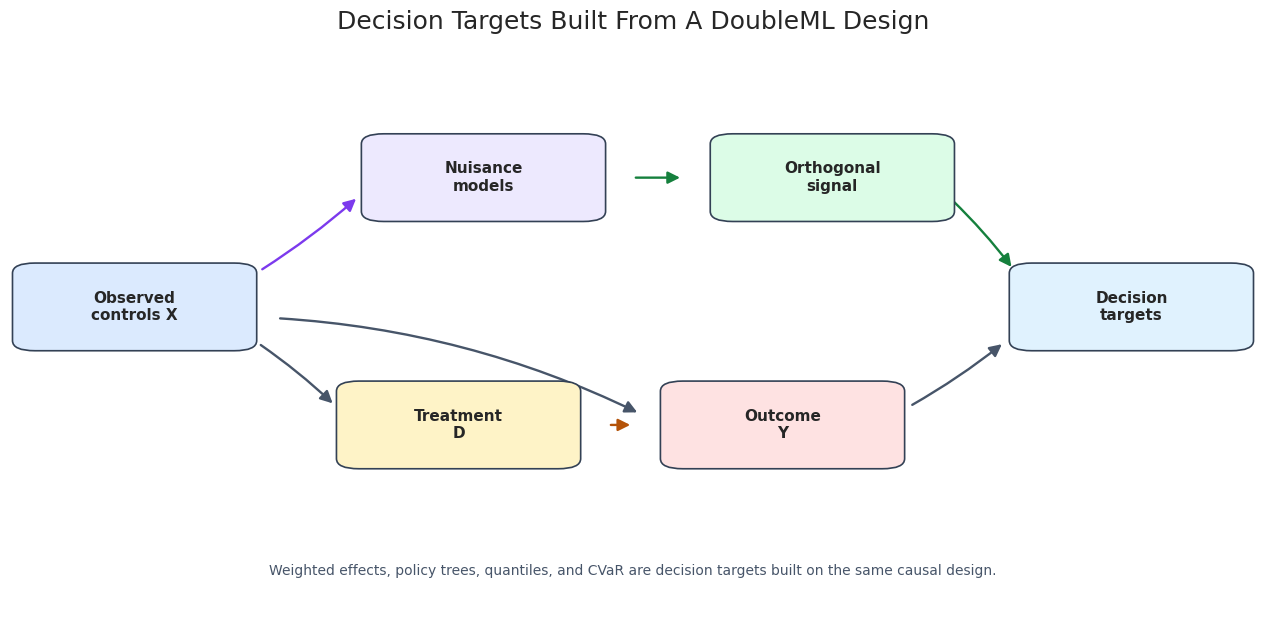

In [6]:
# Define reusable helpers for the Decision Design Diagram section.
fig, ax = plt.subplots(figsize=(13, 6.6))
ax.set_axis_off()
nodes = {
    "X": {"xy": (0.10, 0.55), "label": "Observed\ncontrols X", "color": "#dbeafe"},
    "D": {"xy": (0.36, 0.34), "label": "Treatment\nD", "color": "#fef3c7"},
    "Y": {"xy": (0.62, 0.34), "label": "Outcome\nY", "color": "#fee2e2"},
    "N": {"xy": (0.38, 0.78), "label": "Nuisance\nmodels", "color": "#ede9fe"},
    "S": {"xy": (0.66, 0.78), "label": "Orthogonal\nsignal", "color": "#dcfce7"},
    "T": {"xy": (0.90, 0.55), "label": "Decision\ntargets", "color": "#e0f2fe"},
}
box_w, box_h = 0.16, 0.12
def anchor(node, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    node : object
        Graph node whose position, label, or incident edges are being processed.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[node]["xy"]
    offsets = {
        "left": (-box_w / 2, 0),
        "right": (box_w / 2, 0),
        "top": (0, box_h / 2),
        "bottom": (0, -box_h / 2),
        "upper_right": (box_w / 2, box_h * 0.25),
        "lower_right": (box_w / 2, -box_h * 0.25),
        "upper_left": (-box_w / 2, box_h * 0.25),
        "lower_left": (-box_w / 2, -box_h * 0.25),
    }
    dx, dy = offsets[side]
    return np.array([x + dx, y + dy], dtype=float)
# Keep arrowheads visibly outside the boxes instead of tucking them under the patches.
def shorten(start, end, gap=0.040):
    """
    Idea: Shorten a line segment so the arrowhead remains visible outside the node box.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[float, float]
        Shortened endpoint coordinate that keeps an arrowhead visible.
    """
    start = np.asarray(start, dtype=float)
    end = np.asarray(end, dtype=float)
    delta = end - start
    length = np.hypot(delta[0], delta[1])
    if length == 0:
        return tuple(start), tuple(end)
    unit = delta / length
    return tuple(start + gap * unit), tuple(end - gap * unit)
def draw_arrow(start, end, color="#334155", style="solid", rad=0.0, linewidth=1.7):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    linewidth : object
        Line width used to make the plotted edge or reference line readable.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start, end = shorten(start, end)
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=linewidth,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
        clip_on=False,
    )
    ax.add_patch(arrow)
draw_arrow(anchor("X", "lower_right"), anchor("D", "left"), color="#475569", rad=-0.04)
draw_arrow(anchor("X", "right"), anchor("Y", "left"), color="#475569", rad=-0.10)
draw_arrow(anchor("D", "right"), anchor("Y", "left"), color="#b45309")
draw_arrow(anchor("X", "upper_right"), anchor("N", "left"), color="#7c3aed", rad=0.04)
draw_arrow(anchor("N", "right"), anchor("S", "left"), color="#15803d")
draw_arrow(anchor("S", "right"), anchor("T", "upper_left"), color="#15803d", rad=-0.04)
draw_arrow(anchor("Y", "right"), anchor("T", "lower_left"), color="#475569", rad=0.04)
for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)
ax.text(
    0.50,
    0.08,
    "Weighted effects, policy trees, quantiles, and CVaR are decision targets built on the same causal design.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("Decision Targets Built From A DoubleML Design", pad=18)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_decision_targets_design.png", dpi=160, bbox_inches="tight")
plt.show()


The diagram puts policy learning and distributional summaries after the causal design. This ordering matters: decision tools cannot repair weak identification assumptions.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->


#### Fit the Base DoubleMLIRM Model

We start with a standard `DoubleMLIRM` ATE model. This fitted object will later produce the policy tree. It also provides nuisance predictions for overlap checks.


In [7]:
np.random.seed(RANDOM_SEED)
ml_g = RandomForestRegressor(
    n_estimators=90,
    max_depth=7,
    min_samples_leaf=15,
    random_state=RANDOM_SEED + 1,
    n_jobs=-1,
)
ml_m = RandomForestClassifier(
    n_estimators=90,
    max_depth=6,
    min_samples_leaf=15,
    random_state=RANDOM_SEED + 2,
    n_jobs=-1,
)
base_model = fit_weighted_irm(decision_df, x_cols, ml_g, ml_m, weights=None, n_folds=3)
base_ate = pd.DataFrame([extract_irm_row("Overall ATE", base_model, decision_df["true_effect"])])
save_table(base_ate, f"{NOTEBOOK_PREFIX}_base_ate.csv")
display(base_ate)


,target,estimate,std_error,ci_95_lower,ci_95_upper,oracle_value_in_simulation
0,Overall ATE,0.3472,0.0468,0.2554,0.4390,0.3391


The base ATE estimates the average effect in the full population. This is the reference point for the weighted and policy sections that follow.




### Nuisance Diagnostics

The policy tree and weighted ATEs depend on the same nuisance components. The code below checks cross-fitted outcome predictions, propensity predictions, and overlap.


In [8]:
pred_g0 = base_model.predictions["ml_g0"][:, 0, 0]
pred_g1 = base_model.predictions["ml_g1"][:, 0, 0]
pred_m = np.clip(base_model.predictions["ml_m"][:, 0, 0], 1e-4, 1 - 1e-4)
mask_control = decision_df["treatment"].eq(0).to_numpy()
mask_treated = decision_df["treatment"].eq(1).to_numpy()
nuisance_diagnostics = pd.DataFrame(
    [
        {"diagnostic": "RMSE for untreated outcome model ml_g0", "value": rmse(decision_df.loc[mask_control, "outcome"], pred_g0[mask_control])},
        {"diagnostic": "RMSE for treated outcome model ml_g1", "value": rmse(decision_df.loc[mask_treated, "outcome"], pred_g1[mask_treated])},
        {"diagnostic": "Propensity log loss for ml_m", "value": float(log_loss(decision_df["treatment"], pred_m))},
        {"diagnostic": "Propensity Brier score for ml_m", "value": float(brier_score_loss(decision_df["treatment"], pred_m))},
        {"diagnostic": "Minimum estimated propensity", "value": float(pred_m.min())},
        {"diagnostic": "Maximum estimated propensity", "value": float(pred_m.max())},
    ]
)
save_table(nuisance_diagnostics, f"{NOTEBOOK_PREFIX}_nuisance_diagnostics.csv")
display(nuisance_diagnostics)


,diagnostic,value
0,RMSE for untreated outcome model ml_g0,0.9111
1,RMSE for treated outcome model ml_g1,0.7651
2,Propensity log loss for ml_m,0.6682
3,Propensity Brier score for ml_m,0.2377
4,Minimum estimated propensity,0.1930
5,Maximum estimated propensity,0.7901


The estimated propensity range stays away from zero and one. That supports, but does not prove, the overlap condition needed for policy and weighted-effect targets.


#### Propensity Overlap Plot

This visual check shows whether treated and untreated observations share common support in the estimated propensity score.


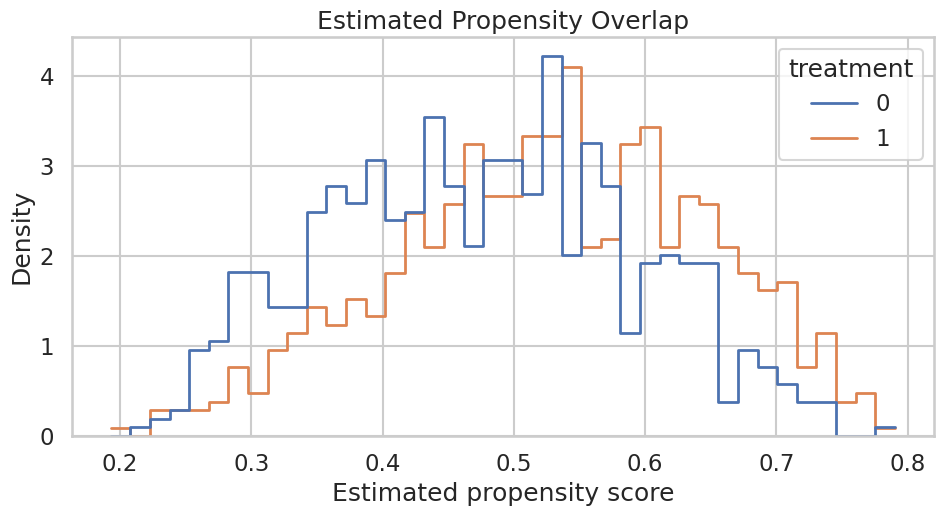

In [9]:
propensity_plot_df = decision_df.assign(estimated_propensity=pred_m)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(
    data=propensity_plot_df,
    x="estimated_propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Estimated Propensity Overlap")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_estimated_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The distributions overlap over most of the range. If one group lived only near zero or one, policy learning would mostly extrapolate from model structure rather than observed comparisons.




#### Weighted ATEs

A weighted ATE changes the target population. In DoubleML, an observation-level weight vector can be passed through `weights=` when using `DoubleMLIRM(score="ATE")`.

The weights below are normalized to have mean one. This keeps the scale comparable while changing which rows receive more influence.


In [10]:
weight_definitions = {
    "Overall ATE": np.ones(len(decision_df)),
    "High-need weighted ATE": normalize_weights(decision_df["need_z"].gt(0.5).astype(float)),
    "High-risk weighted ATE": normalize_weights(decision_df["risk_z"].gt(0.8).astype(float)),
    "High-margin weighted ATE": normalize_weights(decision_df["margin_z"].gt(0.5).astype(float)),
}
weighted_rows = []
weighted_models = {"Overall ATE": base_model}
for label, weights in weight_definitions.items():
    if label == "Overall ATE":
        model = base_model
        model_weights = None
    else:
        model = fit_weighted_irm(decision_df, x_cols, ml_g, ml_m, weights=weights, n_folds=3)
        model_weights = weights
    weighted_models[label] = model
    weighted_rows.append(extract_irm_row(label, model, decision_df["true_effect"], weights=model_weights))
weighted_ate_results = pd.DataFrame(weighted_rows)
save_table(weighted_ate_results, f"{NOTEBOOK_PREFIX}_weighted_ate_results.csv")
display(weighted_ate_results)


,target,estimate,std_error,ci_95_lower,ci_95_upper,oracle_value_in_simulation
0,Overall ATE,0.3472,0.0468,0.2554,0.4390,0.3391
1,High-need weighted ATE,0.6180,0.0918,0.4382,0.7979,0.6022
2,High-risk weighted ATE,-0.0447,0.1244,-0.2885,0.1992,-0.0734
3,High-margin weighted ATE,0.6382,0.0821,0.4773,0.7991,0.5620


The weighted estimates answer different questions. The high-need and high-margin targets emphasize populations where the treatment is designed to help more, while the high-risk target emphasizes a population where the effect is more uncertain and can be lower.


#### Plot Weighted ATEs

The figure below keeps the full-population ATE visible while showing how the target changes under weighting.


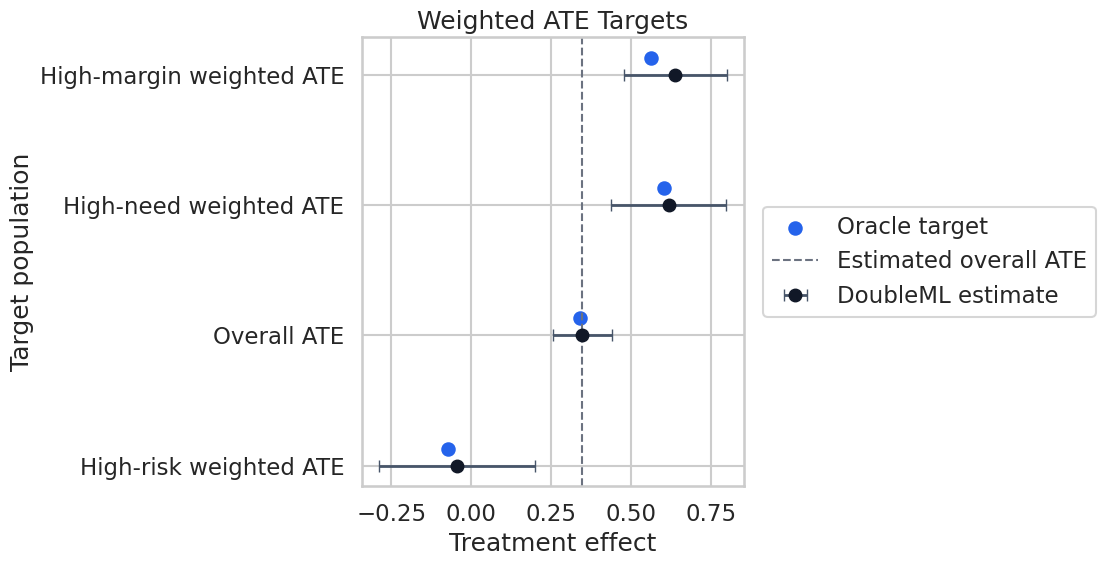

In [11]:
# Build and label the diagnostic visualization for the Plot Weighted ATEs section.
plot_weighted = weighted_ate_results.sort_values("estimate")
y_positions = np.arange(len(plot_weighted))
fig, ax = plt.subplots(figsize=(11.5, 6))
ax.errorbar(
    x=plot_weighted["estimate"],
    y=y_positions,
    xerr=np.vstack([
        plot_weighted["estimate"] - plot_weighted["ci_95_lower"],
        plot_weighted["ci_95_upper"] - plot_weighted["estimate"],
    ]),
    fmt="o",
    color="#111827",
    ecolor="#475569",
    elinewidth=2,
    capsize=4,
    label="DoubleML estimate",
)
ax.scatter(plot_weighted["oracle_value_in_simulation"], y_positions + 0.13, color="#2563eb", s=80, label="Oracle target")
ax.axvline(float(base_model.coef[0]), color="#6b7280", linestyle="--", linewidth=1.5, label="Estimated overall ATE")
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_weighted["target"])
ax.set_title("Weighted ATE Targets")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("Target population")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_weighted_ate_targets.png", dpi=160, bbox_inches="tight")
plt.show()


The plot shows why weighted ATEs are more than cosmetic. They can change the answer by changing the population being averaged over.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->


### Policy Tree

A policy tree turns the orthogonal treatment-benefit signal into a shallow decision rule. DoubleML fits this as a weighted classification problem: the sign of the orthogonal signal says whether treatment appears beneficial, and the magnitude acts like importance weight.

The tree is deliberately shallow. In decision settings, a slightly less flexible rule can be easier to audit, explain, and validate.


In [12]:
policy_features = decision_df[["need_z", "risk_z", "margin_z", "engagement_z"]].copy()
policy_tree_model = base_model.policy_tree(
    policy_features,
    depth=2,
    min_samples_leaf=80,
    ccp_alpha=0.001,
)
policy_predictions = policy_tree_model.predict(policy_features)
policy_rule_text = export_text(
    policy_tree_model.policy_tree,
    feature_names=list(policy_features.columns),
    decimals=2,
)
print(policy_rule_text)
display(policy_tree_model.summary)


|--- risk_z <= 0.81
|   |--- margin_z <= 0.02
|   |   |--- class: 1.0
|   |--- margin_z >  0.02
|   |   |--- class: 1.0
|--- risk_z >  0.81
|   |--- need_z <= 0.02
|   |   |--- class: 0.0
|   |--- need_z >  0.02
|   |   |--- class: 1.0



,Decision Variables,Max Depth
0,need_z,2
1,risk_z,2
2,margin_z,2
3,engagement_z,2


The printed rules are the policy. This is a major advantage of shallow policy trees: the decision logic can be inspected directly instead of only being summarized by a score.


#### Plot the Policy Tree

The plotted tree is saved as a figure so the learned rule can be reviewed without rerunning the lesson.


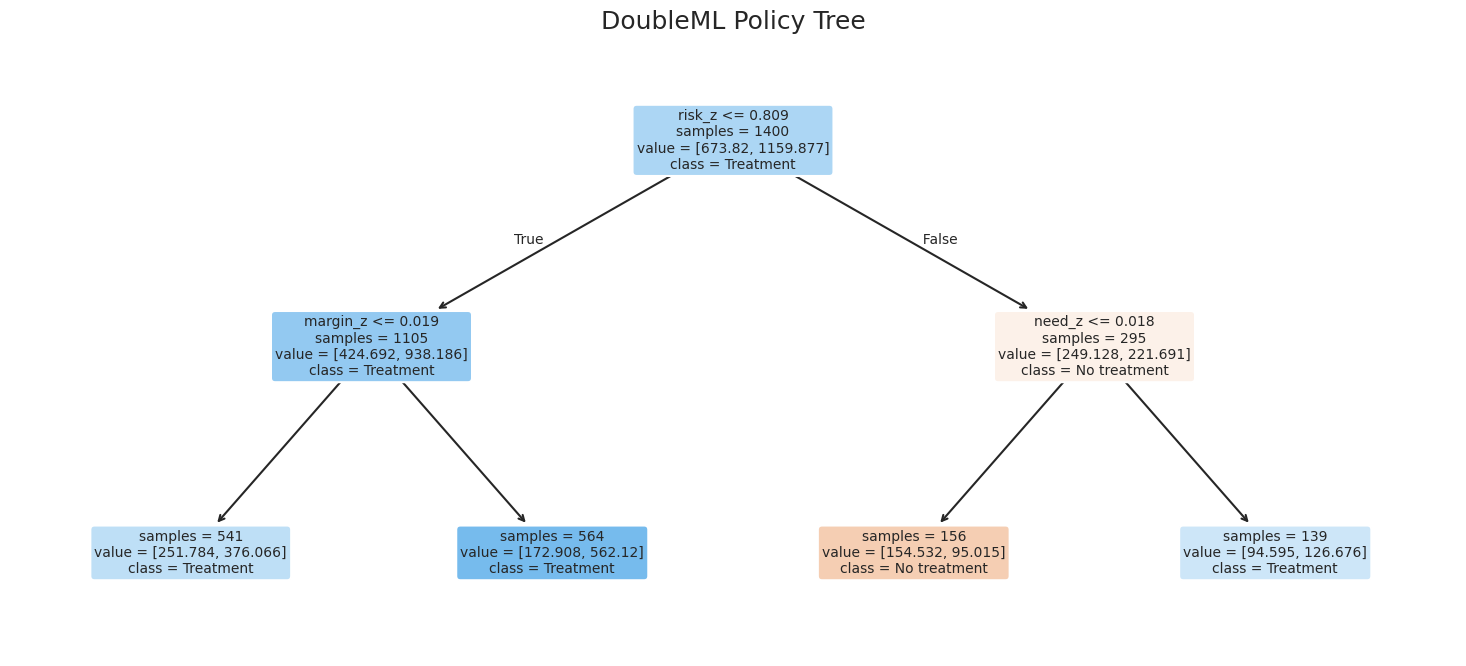

In [13]:
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    policy_tree_model.policy_tree,
    feature_names=list(policy_features.columns),
    class_names=["No treatment", "Treatment"],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=10,
    ax=ax,
)
ax.set_title("DoubleML Policy Tree")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_policy_tree.png", dpi=160, bbox_inches="tight")
plt.show()


The tree should be read as a candidate rule that needs validation before deployment. A production rule would need holdout validation, monitoring, guardrails, and an explicit treatment-cost model.





## Reporting and Takeaways

### Policy Value Summary

The policy tree is optimized against the orthogonal signal `psi_b`. The table below reports two quantities:

- `orthogonal_policy_score`: the score the learned rule is trying to improve.
- `oracle_increment_in_simulation`: the mean true treatment effect among treated-by-policy observations, counting untreated-by-policy observations as zero.

The oracle columns exist only because this is a simulation.


In [14]:
policy_signal = base_model.psi_elements["psi_b"].reshape(-1)
tree_policy = policy_predictions["pred_treatment"].to_numpy().astype(int)
never_policy = np.zeros(len(decision_df), dtype=int)
always_policy = np.ones(len(decision_df), dtype=int)
oracle_positive_policy = decision_df["true_effect"].gt(0).astype(int).to_numpy()
policy_value_rows = []
for label, policy, available in [
    ("Never treat", never_policy, True),
    ("Always treat", always_policy, True),
    ("DoubleML policy tree", tree_policy, True),
    ("Oracle positive-effect policy", oracle_positive_policy, False),
]:
    policy_value_rows.append(
        {
            "policy": label,
            "available_in_real_data": available,
            "treatment_rate": float(policy.mean()),
            "orthogonal_policy_score": float(np.mean(policy * policy_signal)),
            "oracle_increment_in_simulation": float(np.mean(policy * decision_df["true_effect"].to_numpy())),
        }
    )
policy_value_table = pd.DataFrame(policy_value_rows)
save_table(policy_value_table, f"{NOTEBOOK_PREFIX}_policy_value_summary.csv")
display(policy_value_table)


,policy,available_in_real_data,treatment_rate,orthogonal_policy_score,oracle_increment_in_simulation
0,Never treat,True,0.0000,0.0000,0.0000
1,Always treat,True,1.0000,0.3472,0.3391
2,DoubleML policy tree,True,0.8886,0.3897,0.3593
3,Oracle positive-effect policy,False,0.6750,0.5082,0.5046


The policy tree improves on treating nobody and can improve on treating everyone when it avoids enough low-effect cases. The oracle positive-effect policy is an upper benchmark, not an attainable rule in observational data.




### Policy Assignment Diagnostics

A policy rule should be inspected for who it treats. The code below summarizes treatment recommendations by the teaching segments.


In [15]:
policy_assignment_df = decision_df.assign(policy_treat=tree_policy)
policy_segment_summary = (
    policy_assignment_df.groupby("segment")
    .agg(
        n=("outcome", "size"),
        policy_treatment_rate=("policy_treat", "mean"),
        observed_treatment_rate=("treatment", "mean"),
        oracle_effect_mean=("true_effect", "mean"),
    )
    .reset_index()
    .sort_values("policy_treatment_rate", ascending=False)
)
save_table(policy_segment_summary, f"{NOTEBOOK_PREFIX}_policy_assignment_by_segment.csv")
display(policy_segment_summary)


,segment,n,policy_treatment_rate,observed_treatment_rate,oracle_effect_mean
0,general,641,1.0000,0.4883,0.3069
1,high_margin,215,1.0000,0.5535,0.6258
2,high_need,305,1.0000,0.5803,0.5835
3,high_risk,239,0.3473,0.3891,-0.1442


The policy tree tends to treat high-need and high-margin segments more often, while being more selective in the high-risk segment. This is the kind of operational behavior a policy learner should make transparent.




### Plot Policy Assignment by Segment

The plot compares the learned policy treatment rate with the observed historical treatment rate. These are different objects: the observed rate is what happened in the data, while the policy rate is what the learned rule recommends.


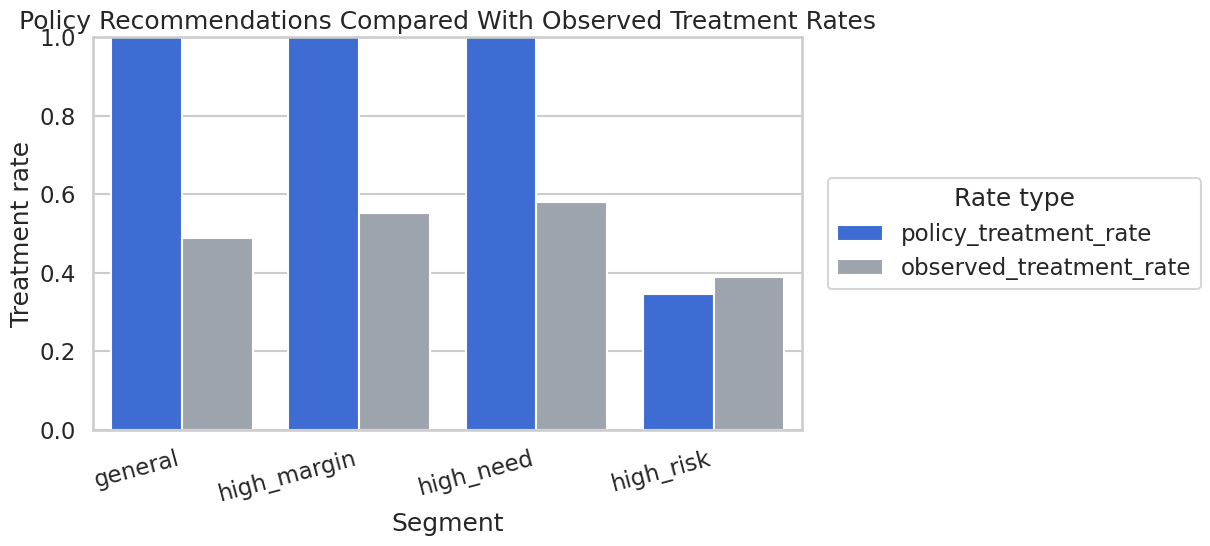

In [16]:
# Build and label the diagnostic visualization for the Plot Policy Assignment By Segment section.
assignment_plot_df = policy_segment_summary.melt(
    id_vars=["segment"],
    value_vars=["policy_treatment_rate", "observed_treatment_rate"],
    var_name="rate_type",
    value_name="rate",
)
fig, ax = plt.subplots(figsize=(12.5, 5.8))
sns.barplot(
    data=assignment_plot_df,
    x="segment",
    y="rate",
    hue="rate_type",
    palette={"policy_treatment_rate": "#2563eb", "observed_treatment_rate": "#9ca3af"},
    ax=ax,
)
ax.set_title("Policy Recommendations Compared With Observed Treatment Rates")
ax.set_xlabel("Segment")
ax.set_ylabel("Treatment rate")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=15)
for tick in ax.get_xticklabels():
    tick.set_ha("right")
ax.legend(title="Rate type", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_policy_assignment_by_segment.png", dpi=160, bbox_inches="tight")
plt.show()


The difference between historical treatment and recommended treatment is a useful audit. Large differences can be promising, but they also raise implementation and extrapolation questions.


### Quantile Treatment Effects

The ATE summarizes the mean. A QTE compares quantiles of the treated and untreated potential-outcome distributions. For example, the 10th-percentile QTE asks whether treatment improves the lower part of the outcome distribution.

A QTE is not the 10th percentile of individual treatment effects. It is the difference between two marginal potential-outcome quantiles.


In [17]:
# Fit or evaluate the model objects used in the Quantile Treatment Effects section.
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
ml_qte_g = RandomForestClassifier(
    n_estimators=70,
    max_depth=6,
    min_samples_leaf=18,
    random_state=RANDOM_SEED + 3,
    n_jobs=-1,
)
ml_qte_m = RandomForestClassifier(
    n_estimators=70,
    max_depth=6,
    min_samples_leaf=18,
    random_state=RANDOM_SEED + 4,
    n_jobs=-1,
)
qte_model = DoubleMLQTE(
    make_irm_data(decision_df, x_cols),
    ml_g=clone(ml_qte_g),
    ml_m=clone(ml_qte_m),
    quantiles=quantiles,
    n_folds=3,
    n_rep=1,
    normalize_ipw=True,
)
qte_model.fit()
qte_results = qte_model.summary.reset_index().rename(columns={"index": "quantile", "2.5 %": "ci_95_lower", "97.5 %": "ci_95_upper"})
qte_results["quantile"] = qte_results["quantile"].astype(float)
qte_results["oracle_qte_in_simulation"] = [
    np.quantile(decision_df["y1_oracle"], q) - np.quantile(decision_df["y0_oracle"], q)
    for q in qte_results["quantile"]
]
save_table(qte_results, f"{NOTEBOOK_PREFIX}_qte_results.csv")
display(qte_results)


,quantile,coef,std err,t,P>|t|,ci_95_lower,ci_95_upper,oracle_qte_in_simulation
0,0.1000,-0.0381,0.1504,-0.2531,0.8002,-0.3328,0.2567,0.0229
1,0.2500,0.2337,0.0852,2.7435,0.0061,0.0667,0.4006,0.1857
2,0.5000,0.3111,0.0667,4.6644,0.0000,0.1804,0.4419,0.2788
3,0.7500,0.4406,0.0697,6.3206,0.0000,0.3040,0.5773,0.3816
4,0.9000,0.7510,0.0927,8.1015,0.0000,0.5693,0.9326,0.6039


The QTE table shows whether the treatment effect differs across the outcome distribution. In this synthetic design, distributional effects matter because treatment partly mitigates downside shocks.


### Plot Quantile Treatment Effects

The QTE plot makes the distributional pattern easier to scan than a table. The oracle points are available only because this is simulated data.


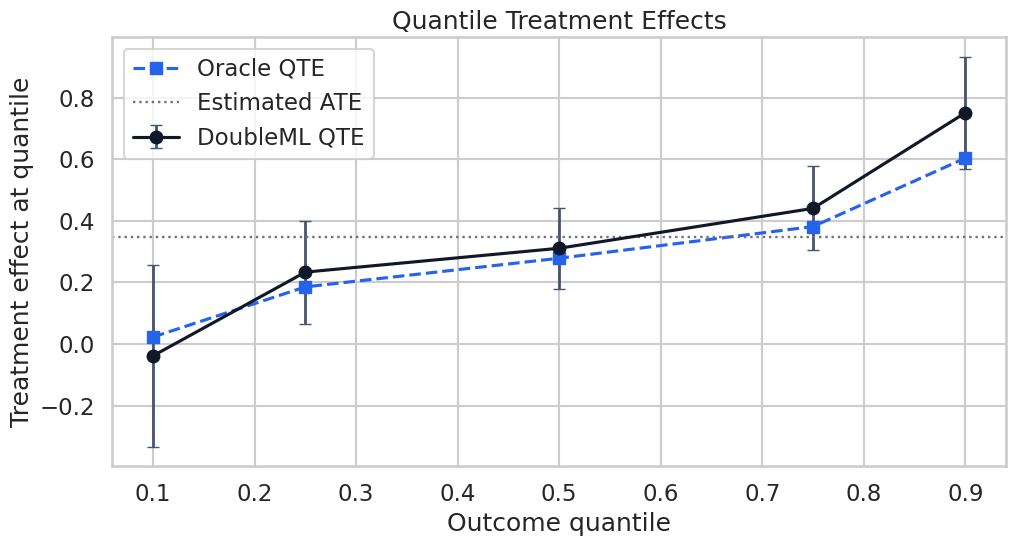

In [18]:
# Build and label the diagnostic visualization for the Plot Quantile Treatment Effects section.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.errorbar(
    x=qte_results["quantile"],
    y=qte_results["coef"],
    yerr=np.vstack([
        qte_results["coef"] - qte_results["ci_95_lower"],
        qte_results["ci_95_upper"] - qte_results["coef"],
    ]),
    fmt="o-",
    color="#111827",
    ecolor="#475569",
    elinewidth=2,
    capsize=4,
    label="DoubleML QTE",
)
ax.plot(
    qte_results["quantile"],
    qte_results["oracle_qte_in_simulation"],
    marker="s",
    linestyle="--",
    color="#2563eb",
    label="Oracle QTE",
)
ax.axhline(float(base_model.coef[0]), color="#6b7280", linestyle=":", linewidth=1.7, label="Estimated ATE")
ax.set_title("Quantile Treatment Effects")
ax.set_xlabel("Outcome quantile")
ax.set_ylabel("Treatment effect at quantile")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_qte_results.png", dpi=160, bbox_inches="tight")
plt.show()


The curve shows why distribution-aware targets can change the conversation. If lower-tail effects are large, the treatment may be valuable as a risk-reduction tool even when the average effect is only moderate.


#### CVaR for Potential Outcomes

CVaR is a tail-average target. With an outcome where higher is better, lower-tail CVaR at `alpha=0.10` is the average outcome among the worst 10% of the potential-outcome distribution.

`DoubleMLCVAR` estimates the CVaR of a chosen potential outcome, selected by `treatment=0` or `treatment=1`. We fit both and compare them descriptively.


In [19]:
# Fit or evaluate the model objects used in the CVaR For Potential Outcomes section.
cvar_alphas = [0.10, 0.20]
cvar_rows = []
cvar_models = {}
for alpha in cvar_alphas:
    for treatment_value in [0, 1]:
        cvar_model = DoubleMLCVAR(
            make_irm_data(decision_df, x_cols),
            ml_g=clone(ml_g),
            ml_m=clone(ml_m),
            treatment=treatment_value,
            quantile=alpha,
            n_folds=3,
            n_rep=1,
            normalize_ipw=True,
        )
        cvar_model.fit()
        cvar_models[(alpha, treatment_value)] = cvar_model
        cvar_ci = cvar_model.confint()
        oracle_column = "y1_oracle" if treatment_value == 1 else "y0_oracle"
        cvar_rows.append(
            {
                "alpha": alpha,
                "potential_outcome": f"Y({treatment_value})",
                "estimate": float(cvar_model.coef[0]),
                "std_error": float(cvar_model.se[0]),
                "ci_95_lower": float(cvar_ci.iloc[0, 0]),
                "ci_95_upper": float(cvar_ci.iloc[0, 1]),
                "oracle_cvar_in_simulation": lower_tail_cvar(decision_df[oracle_column], alpha),
            }
        )
cvar_results = pd.DataFrame(cvar_rows)
save_table(cvar_results, f"{NOTEBOOK_PREFIX}_cvar_potential_outcomes.csv")
display(cvar_results)


,alpha,potential_outcome,estimate,std_error,ci_95_lower,ci_95_upper,oracle_cvar_in_simulation
0,0.1000,Y(0),1.3330,0.0390,1.2565,1.4095,-1.3239
1,0.1000,Y(1),1.7307,0.0454,1.6418,1.8196,-1.0520
2,0.2000,Y(0),1.5246,0.0400,1.4461,1.6031,-0.7005
3,0.2000,Y(1),1.9292,0.0430,1.8449,2.0135,-0.5058


The potential-outcome CVaR estimates are levels, not treatment effects by themselves. The difference between `Y(1)` and `Y(0)` lower-tail CVaR is a tail-risk improvement summary.




#### CVaR Difference Summary

The code below computes a descriptive treated-minus-control CVaR difference from the two fitted potential-outcome CVaRs. The interval is not reported as a formal joint interval because the two estimates are fitted separately here.


In [20]:
cvar_difference_rows = []
for alpha in cvar_alphas:
    treated = cvar_results.query("alpha == @alpha and potential_outcome == 'Y(1)'").iloc[0]
    control = cvar_results.query("alpha == @alpha and potential_outcome == 'Y(0)'").iloc[0]
    cvar_difference_rows.append(
        {
            "alpha": alpha,
            "estimated_tail_improvement": treated["estimate"] - control["estimate"],
            "oracle_tail_improvement": treated["oracle_cvar_in_simulation"] - control["oracle_cvar_in_simulation"],
            "note": "Difference of separately estimated potential-outcome CVaRs; treat uncertainty descriptively here.",
        }
    )
cvar_difference = pd.DataFrame(cvar_difference_rows)
save_table(cvar_difference, f"{NOTEBOOK_PREFIX}_cvar_tail_improvement.csv")
display(cvar_difference)


,alpha,estimated_tail_improvement,oracle_tail_improvement,note
0,0.1000,0.3977,0.2718,Difference of separately estimated potential-outcome CVaRs; treat uncertainty descriptively here.
1,0.2000,0.4046,0.1947,Difference of separately estimated potential-outcome CVaRs; treat uncertainty descriptively here.


The tail-improvement summary is useful when downside outcomes are operationally important. It is not a replacement for the ATE or QTE; it answers a different risk-focused question.




#### Plot CVaR Potential Outcomes

This plot shows the estimated lower-tail potential-outcome levels for treatment and control at each alpha.


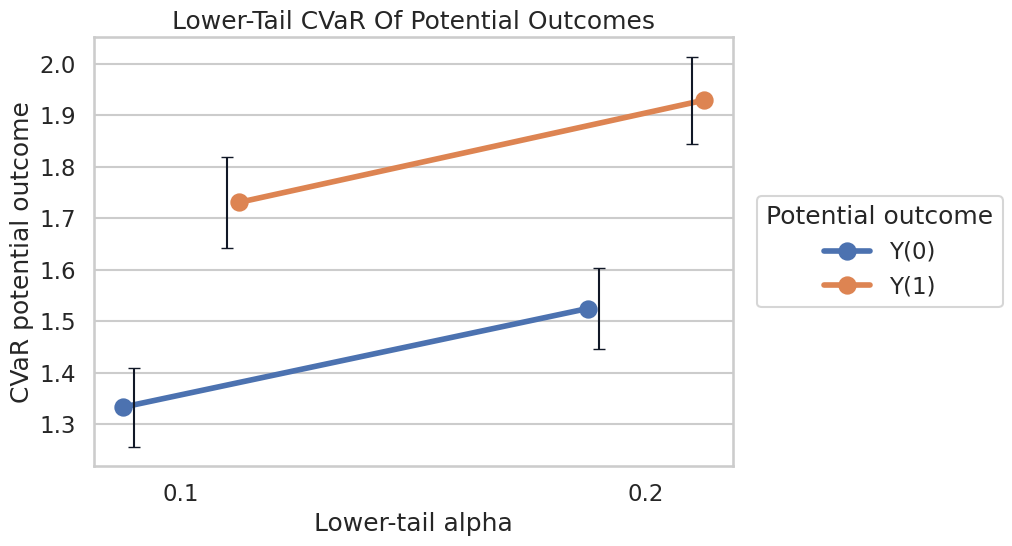

In [21]:
# Build and label the diagnostic visualization for the Plot CVaR Potential Outcomes section.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
sns.pointplot(
    data=cvar_results,
    x="alpha",
    y="estimate",
    hue="potential_outcome",
    dodge=0.25,
    errorbar=None,
    markers="o",
    linestyles="-",
    ax=ax,
)
# Add confidence intervals manually so they line up with the dodged points.
alpha_positions = {alpha: idx for idx, alpha in enumerate(sorted(cvar_results["alpha"].unique()))}
offsets = {"Y(0)": -0.10, "Y(1)": 0.10}
for _, row in cvar_results.iterrows():
    x = alpha_positions[row["alpha"]] + offsets[row["potential_outcome"]]
    ax.errorbar(
        x=x,
        y=row["estimate"],
        yerr=[[row["estimate"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["estimate"]]],
        fmt="none",
        color="#111827",
        capsize=4,
        linewidth=1.5,
    )
ax.set_title("Lower-Tail CVaR Of Potential Outcomes")
ax.set_xlabel("Lower-tail alpha")
ax.set_ylabel("CVaR potential outcome")
ax.legend(title="Potential outcome", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cvar_potential_outcomes.png", dpi=160, bbox_inches="tight")
plt.show()


The treated potential outcome has a higher lower-tail CVaR in this simulation, which means treatment improves the worst-outcome tail. This is the risk-reduction story that an ATE alone can hide.


#### Bring the Decision Targets Together

The table below summarizes how each target should be used. This is the kind of table that helps prevent a decision review from collapsing all causal outputs into one number.


In [22]:
decision_target_summary = pd.DataFrame(
    [
        {
            "target": "Overall ATE",
            "main_output": f"{float(base_model.coef[0]):.3f}",
            "use_when": "You need a population-average effect.",
            "main_caution": "Can hide subgroup and distributional variation.",
        },
        {
            "target": "Weighted ATE",
            "main_output": "See weighted ATE table",
            "use_when": "A priority population matters more than the full sample.",
            "main_caution": "Weights define a new estimand and must be justified before analysis.",
        },
        {
            "target": "Policy tree",
            "main_output": f"Treatment rate {tree_policy.mean():.2%}",
            "use_when": "You need a simple candidate targeting rule.",
            "main_caution": "Needs validation, capacity/cost checks, and monitoring before use.",
        },
        {
            "target": "QTE",
            "main_output": "See quantile curve",
            "use_when": "You care about distributional shifts along with the mean.",
            "main_caution": "QTE is a difference in potential-outcome quantiles, not a quantile of individual effects.",
        },
        {
            "target": "CVaR",
            "main_output": "See lower-tail table",
            "use_when": "Downside-risk outcomes are especially important.",
            "main_caution": "Tail estimates can be noisier and need careful uncertainty handling.",
        },
    ]
)
save_table(decision_target_summary, f"{NOTEBOOK_PREFIX}_decision_target_summary.csv")
display(decision_target_summary)


,target,main_output,use_when,main_caution
0,Overall ATE,0.347,You need a population-average effect.,Can hide subgroup and distributional variation.
1,Weighted ATE,See weighted ATE table,A priority population matters more than the full sample.,Weights define a new estimand and must be justified before analysis.
2,Policy tree,Treatment rate 88.86%,You need a simple candidate targeting rule.,"Needs validation, capacity/cost checks, and monitoring before use."
3,QTE,See quantile curve,You care about distributional shifts along with the mean.,"QTE is a difference in potential-outcome quantiles, not a quantile of individual effects."
4,CVaR,See lower-tail table,Downside-risk outcomes are especially important.,Tail estimates can be noisier and need careful uncertainty handling.


This table is deliberately practical. It says what each estimator produces and when the output should and should not drive a decision.




#### Reporting Checklist

The checklist below is reusable across decision-target analyses. It emphasizes pre-specification, target clarity, and validation.


| item | guidance |
| --- | --- |
| Target definition | State whether the target is ATE, weighted ATE, policy value, QTE, or CVaR. |
| Weight justification | If using weights, explain the target population and normalize weights transparently. |
| Policy constraints | State treatment costs, capacity limits, fairness constraints, and monitoring needs. |
| Distributional framing | For QTE and CVaR, explain why mean effects are not enough. |
| Overlap | Show propensity overlap, especially for weighted and tail-focused targets. |
| Validation | Validate candidate policies and distributional claims on held-out data or future experiments. |
| Decision boundary | Separate evidence for prioritization from evidence for automatic deployment. |


The checklist keeps the analysis grounded. More advanced targets can be more useful, but they also create more ways to overstate what the data supports.


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


The template forces the report to keep target choice and decision choice separate. That separation is one of the best habits in applied causal work.


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


## What Comes Next

The sequence next moves to custom scores and the advanced API. Built-in decision-target tools are useful, and the next step is to extend DoubleML when the estimand or score is not already covered by a standard class.

The main lesson here is straightforward. Better decision targets still require feasibility, uncertainty, and guardrail checks. Weighted ATEs, policy trees, QTEs, and CVaR are powerful because they make the decision question sharper. They still need credible identification, honest uncertainty, and validation before action.
